In [14]:
import numpy as np
import torch
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [15]:
class PCA():
    """
    PCA implementation.

    Attributes:
        C (np.ndarray): Mean vector of shape (d,).
        U (np.ndarray): Principal directions of shape (d, d), where each
            column represents a principal component.
        D (np.ndarray): Principal values of shape (d,), sorted in
            descending order.
    """

    def __init__(self, Xtrain):
        """
        Initializes PCA components from the training data.

        Args:
            Xtrain (np.ndarray): Training dataset of shape (n, d),
                where n is the number of samples and d is the number
                of features.
        """
        self.C = np.mean(Xtrain, axis=0)

        N = Xtrain.shape[0]
        Z = Xtrain - self.C

        U, S, _ = np.linalg.svd(Z.T)

        self.U = U
        self.D = S ** 2 / (N - 1)

    def project(self, Xtest, m):
        """
        Projects test data onto the first m principal components.

        The method centers the data using the training mean and
        projects it into the m-dimensional PCA subspace.

        Returns a matrix Z of shape (n, m), where n is the number
        of test samples.

        Args:
            Xtest (np.ndarray): Test dataset of shape (n, d).
            m (int): Number of principal components to use.

        Returns:
            np.ndarray: Projected data of shape (n, m).
        """
        U_m = self.U[:, :m]
        Z = (Xtest - self.C) @ U_m

        return Z

    def denoise(self, Xtest, m):
        """
        Reconstructs (denoises) the input data using the first m
        principal components.

        The method projects the data into the m-dimensional PCA space
        and reconstructs it back into the original d-dimensional space.

        Returns a matrix Y of shape (n, d), where n is the number
        of test samples.

        Args:
            Xtest (np.ndarray): Test dataset of shape (n, d).
            m (int): Number of principal components to use.

        Returns:
            np.ndarray: Reconstructed (denoised) data of shape (n, d).
        """
        Z = self.project(Xtest, m)
        U_m = self.U[:, :m]

        Y = Z @ U_m.T + self.C
        return Y

In [16]:
data = loadmat("problem_set1/data/usps.mat")

In [17]:
X = data["data_patterns"].T
y = data["data_labels"].T.argmax(axis=1)

In [18]:
pca = PCA(X)

In [19]:
from sklearn.decomposition import PCA

# kreiraj PCA objekat (bez ograničenja broja komponenti)
pca1 = PCA()
pca1.fit(X)

# rezultati
eigenvalues = pca1.explained_variance_
eigenvectors = pca1.components_.T

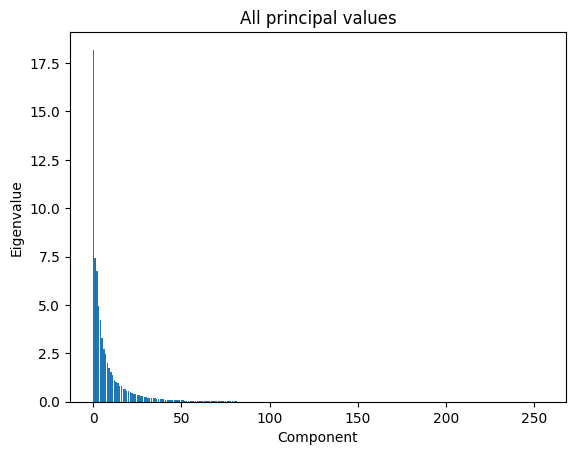

In [20]:
plt.figure()
plt.bar(np.arange(len(pca.D)), pca.D)
plt.title("All principal values")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

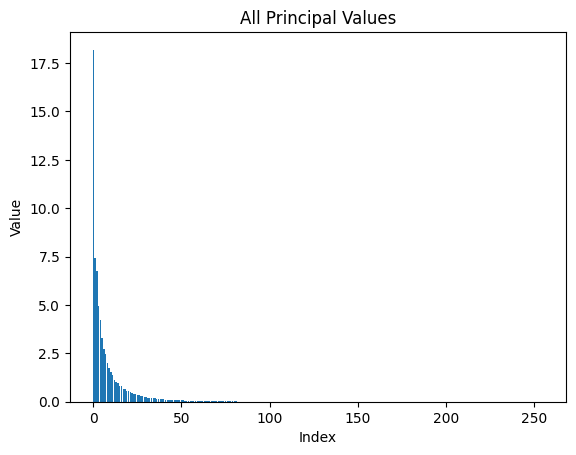

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.title("All Principal Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

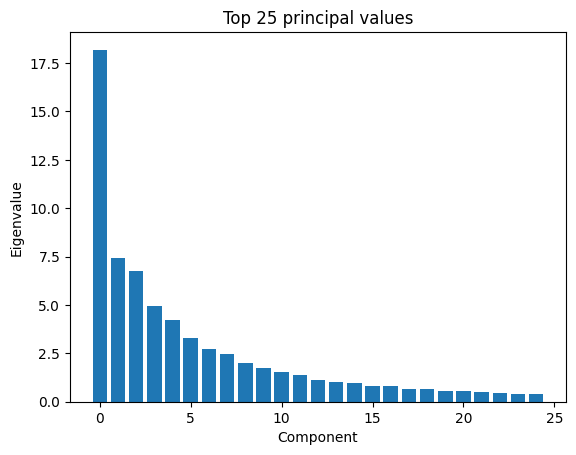

In [22]:
plt.figure()
plt.bar(np.arange(25), pca.D[:25])
plt.title("Top 25 principal values")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

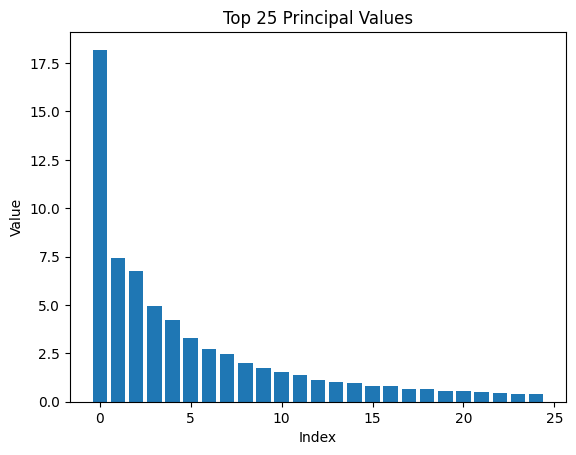

In [23]:
plt.figure()
plt.bar(range(25), eigenvalues[:25])
plt.title("Top 25 Principal Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

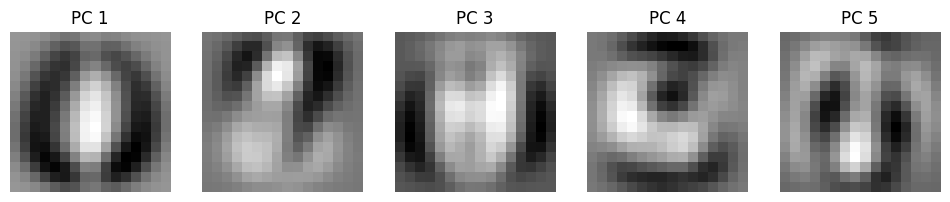

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    img = pca.U[:, i].reshape(16, 16)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis("off")

plt.show()

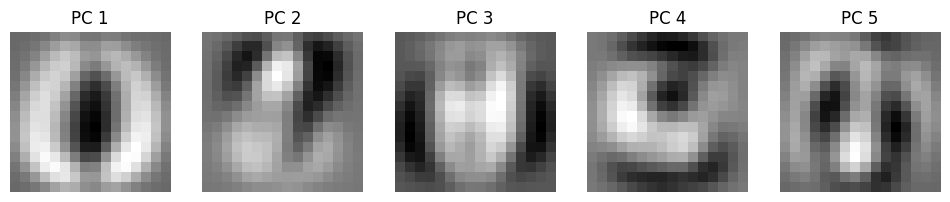

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    img = eigenvectors[:, i].reshape(16, 16)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis("off")

plt.show()